In [1]:
using ArgParse
using Dates
using JLD2
using Printf

using StatsBase
using Graphs
using SimpleWeightedGraphs
# using BlossomV
using GraphsMatching


const ROOT = normpath(joinpath(@__DIR__, ".."))

include(joinpath(ROOT, "src", "circuits.jl"))
include(joinpath(ROOT, "src", "local.jl"))
include(joinpath(ROOT, "src", "main.jl"))
include(joinpath(ROOT, "src", "mwpm.jl"))

basic_correct (generic function with 1 method)

In [2]:
using Plots

In [4]:
function adv_MWPM_sample(L::Int, T::Int, p::Float64, peff::Float64, q::Float64)
    ρ = initialstate(L)
    Ms = zeros(Float64, T+1)

    for t in 1:T
        ρ = noiselayer(ρ, p)
        ρ = correct(ρ, peff, q)
        Ms[t+1] = magnetization(ρ)
    end

    return Ms
end

adv_MWPM_sample (generic function with 2 methods)

In [3]:
function correct(ρ::AbstractMatrix, peff::Float64, q::Float64)
    checks = measure(ρ, q)
    
    horizontal_checks, vertical_checks = heal(checks, peff, q)
    domain = track_domains((horizontal_checks, vertical_checks))
    if magnetization(domain) > 0.5
        domain = .!domain
    end
    
    return ρ .⊻ domain
end

correct (generic function with 1 method)

In [5]:
function detect_charges(horizontal_checks::AbstractMatrix, vertical_checks::AbstractMatrix)
    L = size(vertical_checks)[1]
    sites = vertical_checks .⊻ horizontal_checks .⊻ circshift(vertical_checks,(-1,0)) .⊻ circshift(horizontal_checks,(0,-1))
    return [(j,i) for i in 1:L, j in 1:L][Bool.(sites)]
end

prob_weight(x::Float64) = -log(x/(1-x))
weight(peff::Float64, q::Float64, m::Bool) = q > 0 ? ((-1)^m * prob_weight(peff) + prob_weight(q)) : (m == true ? 0.0 : Inf)

site(L,x,y) = L*(mod1(y,L)-1)+mod1(x,L)
unsite(L,s) = (mod1(s,L), div(s-1,L)+1)

function build_matching_graph(checks::Tuple, peff::Float64, q::Float64)
    horizontal_checks, vertical_checks = checks
    L = size(horizontal_checks)[1]
    
    sources = [site(L,x,y) for y in 1:L for x in 1:L]
    horizontal_destinations = [site(L,x+1,y) for y in 1:L for x in 1:L]
    vertical_destinations = [site(L,x,y+1) for y in 1:L for x in 1:L]
    
    horizontal_weights = weight.(peff, q, Bool.(horizontal_checks))
    horizontal_weights[end,:] .= 0
    horizontal_weights = reshape(circshift(horizontal_weights,(0,-1))', L^2, 1)[:,1]

    vertical_weights = weight.(peff, q, Bool.(vertical_checks))
    vertical_weights[:,end] .= 0
    vertical_weights = reshape(circshift(vertical_weights,(-1,0))', L^2, 1)[:,1]
    
    return SimpleWeightedGraph([sources; sources], [horizontal_destinations; vertical_destinations], [horizontal_weights; vertical_weights])
end

function match_charges(fw::Graphs.FloydWarshallState, charges::Vector, L::Int; depth=50)
    subgraph = complete_graph(length(charges))
    weights = Dict{Edge,Float64}()
    for i in 1:length(charges)-1
        for j in i+1:length(charges)
            # if fw.dists[charges[i],charges[j]] < Inf
                weights[Edge(i, j)] = fw.dists[site(L,charges[i]...),site(L,charges[j]...)]
            # end
        end
    end

    match = minimum_weight_perfect_matching(subgraph, weights, depth)
    return match
end

function boundary_filter(checks::Tuple)
    horizontal_checks, vertical_checks = deepcopy(checks)
    L = size(horizontal_checks)[1]
    
    horizontal_checks[end,:] .= false
    vertical_checks[:,end] .= false
    
    return horizontal_checks, vertical_checks
end

cyclicmax(L, a, b) = mod(a-b-1, L) == 0 ? a : b 


function heal(checks::Tuple, peff::Float64, q::Float64)
    t1 = time()
    horizontal_checks, vertical_checks = deepcopy(boundary_filter(checks))
    L = size(horizontal_checks)[1]
    charges = detect_charges(horizontal_checks, vertical_checks)

    # println(charges)

    if length(charges) == 0
        return horizontal_checks, vertical_checks
    end
    
    g = build_matching_graph((horizontal_checks, vertical_checks), peff, q)
    fw = floyd_warshall_shortest_paths(g)
    match = match_charges(fw, charges, L)


    t2 = time()

    horizontal_checks, vertical_checks = apply_paths((horizontal_checks, vertical_checks), fw, match, charges, L)

    # println("Matching took $(t2 - t1) seconds.")
    # println("Pathing took $(time() - t2) seconds.")

    return horizontal_checks, vertical_checks
end

function apply_paths(checks::Tuple, fw::Graphs.FloydWarshallState, match::MatchingResult, charges::Vector, L::Int)
    horizontal_checks, vertical_checks = checks
    mated = Int[]
    

    for i in 1:length(charges)
        j = match.mate[i]
        if j in mated
            continue
        end

        # while loop path backwards
        
        s0 = site(L, charges[i]...)
        s2 = site(L, charges[j]...)
        while s0 != s2
            s1 = fw.parents[s0, s2]
            x1, y1 = unsite(L, s1)
            x2, y2 = unsite(L, s2)
            if x1 == x2
                vertical_checks[cyclicmax(L, y1, y2), x1] ⊻= true
            elseif y1 == y2
                horizontal_checks[y1, cyclicmax(L, x1, x2)] ⊻= true
            end

            s2 = s1
        end

        push!(mated, i)
        push!(mated, j)
    end
    return horizontal_checks, vertical_checks
end

apply_paths (generic function with 1 method)

In [6]:
data = Dict{Tuple{Int, Float64, Float64, Float64}, Vector{Float64}}()

Dict{Tuple{Int64, Float64, Float64, Float64}, Vector{Float64}}()

In [7]:
samples = 1

for p in 0.0:0.02:0.3
    for q in 0.0:0.02:0.3
        peff = q
        for L in [8]
            T = 2L

            M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
            data[(L, p, q, peff)] = M1s
        end
    end
end

In [10]:
data1 = load("/Users/jhauser/Code/single_shot/output/sample_algo=adv_MWPM_L=8_T=8_p=0p000_q=0p000_peff=0p000_samples=1_20260225_031600_49851494.jld2")
data2 = load("/Users/jhauser/Code/single_shot/output/sample_algo=adv_MWPM_L=8_T=8_p=0p050_q=0p100_peff=0p150_samples=1_20260225_031628_2568296471.jld2")

Dict{String, Any} with 10 entries:
  "T"       => 8
  "samples" => 1
  "algo"    => "adv_MWPM"
  "peff"    => 0.15
  "M1s"     => [0.0, 0.0, 0.015625, 0.015625, 0.015625, 0.0, 0.0, 0.0, 0.046875]
  "dt"      => 0.0910211
  "L"       => 8
  "q"       => 0.1
  "M2s"     => [0.0, 0.0, 0.000244141, 0.000244141, 0.000244141, 0.0, 0.0, 0.0,…
  "p"       => 0.05

In [13]:
data3 = load("/Users/jhauser/Code/single_shot/sample_algo=adv_MWPM_L=8_T=80_p=0p000_q=0p000_peff=0p000_samples=2_20260225_054147_1633217428.jld2")

Dict{String, Any} with 10 entries:
  "T"       => 80
  "samples" => 2
  "algo"    => "adv_MWPM"
  "peff"    => 0.0
  "M1s"     => [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, …
  "dt"      => 0.0577822
  "L"       => 8
  "q"       => 0.0
  "M2s"     => [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, …
  "p"       => 0.0

In [284]:
# include(joinpath(ROOT, "src", "mwpm.jl"))

L = 60
p = 0.1
q = 0.1
peff = q
T = 2L
samples = 10
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)

# each job can be 10L & 10k samples

([0.0, 0.04055555555555555, 0.05897222222222222, 0.06613888888888889, 0.07152777777777779, 0.07625000000000001, 0.08227777777777778, 0.08566666666666665, 0.08438888888888887, 0.08408333333333333  …  0.10236111111111112, 0.09958333333333333, 0.10169444444444445, 0.10188888888888888, 0.10472222222222223, 0.10375000000000001, 0.10102777777777779, 0.10147222222222223, 0.10469444444444445, 0.10280555555555557], [0.0, 0.0016729475308641978, 0.0035290354938271604, 0.004419683641975309, 0.005189760802469136, 0.005921288580246914, 0.0068410956790123465, 0.00739425925925926, 0.00717645061728395, 0.007160686728395062  …  0.010727646604938273, 0.010203341049382714, 0.01052954475308642, 0.01055625, 0.011143256172839506, 0.010867291666666667, 0.010386242283950615, 0.010677739197530865, 0.01150315586419753, 0.010921149691358024])

In [286]:
# include(joinpath(ROOT, "src", "mwpm.jl"))

L = 30
p = 0.1
q = 0.1
peff = q
T = 2L
samples = 10
MM1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)

# each job can be 10L & 10k samples

([0.0, 0.03933333333333333, 0.05533333333333333, 0.06444444444444444, 0.06077777777777778, 0.06288888888888888, 0.06777777777777777, 0.07377777777777778, 0.08611111111111111, 0.08711111111111111  …  0.10811111111111112, 0.10466666666666666, 0.10711111111111109, 0.10899999999999999, 0.10544444444444442, 0.10833333333333335, 0.10444444444444445, 0.10699999999999998, 0.10455555555555554, 0.10211111111111111], [0.0, 0.001634320987654321, 0.003137530864197531, 0.004302469135802469, 0.0038556790123456795, 0.004132098765432099, 0.00489679012345679, 0.005683209876543209, 0.007592222222222221, 0.007738024691358025  …  0.012789506172839507, 0.012523209876543212, 0.013214074074074076, 0.01384679012345679, 0.012484567901234565, 0.013196913580246914, 0.011909135802469134, 0.012569012345679012, 0.012224567901234568, 0.012609506172839508])

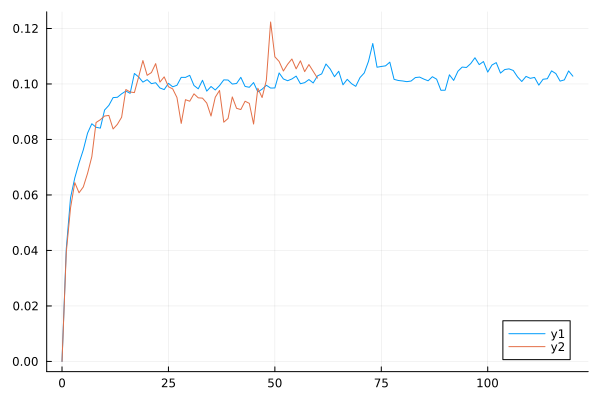

In [288]:
plot(0:120, M1s)
plot!(0:60, MM1s)

In [281]:
# include(joinpath(ROOT, "src", "mwpm.jl"))

L = 16
p = 0.1
q = 0.1
peff = q+0.05
T = 2L
samples = 1
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)

# each job can be 10L & 10k samples

([0.0, 0.02734375, 0.05078125, 0.140625, 0.12890625, 0.1015625, 0.0546875, 0.0546875, 0.0625, 0.07421875  …  0.140625, 0.08203125, 0.0703125, 0.05078125, 0.06640625, 0.046875, 0.04296875, 0.0546875, 0.07421875, 0.375], [0.0, 0.0007476806640625, 0.0025787353515625, 0.019775390625, 0.0166168212890625, 0.01031494140625, 0.00299072265625, 0.00299072265625, 0.00390625, 0.0055084228515625  …  0.019775390625, 0.0067291259765625, 0.00494384765625, 0.0025787353515625, 0.0044097900390625, 0.002197265625, 0.0018463134765625, 0.00299072265625, 0.0055084228515625, 0.140625])

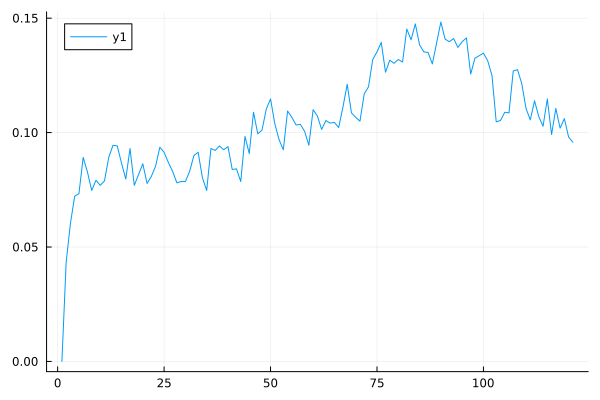

In [283]:
plot(M1s)

In [6]:
ρ = [0 0 0 0
     0 1 0 0
     0 0 0 0
     0 0 0 0]

measure(ρ, 0.0)

([0 1 0 0; 0 1 0 0; 0 0 0 0; 0 0 0 0], [0 0 0 0; 1 1 0 0; 0 0 0 0; 0 0 0 0])

In [7]:
horizontal_checks = Bool[0 1 1 0; 0 1 0 0; 0 0 0 0; 0 0 0 0]
vertical_checks = Bool[0 0 0 0; 1 1 0 0; 0 0 0 0; 0 1 0 0]
horizontal_checks

4×4 Matrix{Bool}:
 0  1  1  0
 0  1  0  0
 0  0  0  0
 0  0  0  0

In [229]:
vertical_checks

4×4 Matrix{Bool}:
 0  0  0  0
 1  1  0  0
 0  0  0  0
 0  1  0  0

In [227]:
detect_charges(horizontal_checks, vertical_checks)

4-element Vector{Tuple{Int64, Int64}}:
 (2, 1)
 (2, 3)
 (2, 4)
 (3, 1)

In [245]:
checks = (BitMatrix(horizontal_checks), BitMatrix(vertical_checks))
horizontal_checks, vertical_checks = deepcopy(boundary_filter(checks))
L = size(horizontal_checks)[1]
charges = detect_charges(horizontal_checks, vertical_checks)

g = build_matching_graph_syndrome_only((horizontal_checks, vertical_checks))

fw = floyd_warshall_shortest_paths(g)
match = match_charges(fw, charges, L)

MatchingResult{Float64}(0.0, [2, 1, 4, 3])

In [248]:
subgraph = complete_graph(length(charges))
# println(length(charges))
weights = Dict{Edge,Float64}()
for i in 1:length(charges)-1
    for j in i+1:length(charges)
        if fw.dists[site(L,charges[i]...),site(L,charges[j]...)] < Inf
            weights[Edge(i, j)] = fw.dists[site(L,charges[i]...),site(L,charges[j]...)]
        else
            weights[Edge(i, j)] = 1000.0
        end
    end
end

match = minimum_weight_perfect_matching(subgraph, weights, 50)

MatchingResult{Float64}(0.0, [2, 1, 4, 3])

In [249]:
weights

Dict{Graphs.SimpleGraphs.SimpleEdge, Float64} with 6 entries:
  Edge 2 => 4 => 1000.0
  Edge 1 => 2 => 1000.0
  Edge 1 => 3 => 1000.0
  Edge 3 => 4 => 1000.0
  Edge 1 => 4 => 1.0
  Edge 2 => 3 => 1.0

In [271]:
subgraph = complete_graph(4)
weights = Dict([Edge(1,2) => 1000.0,
                Edge(1,3) => 1000.0,
                Edge(1,4) => 1.0,
                Edge(2,3) => 1.0,
                Edge(2,4) => 1000.0,
                Edge(3,4) => 1000.0])
match = minimum_weight_perfect_matching(subgraph, weights)
match.mate[1]

4

In [309]:
include(joinpath(ROOT, "src", "mwpm.jl"))

basic_correct (generic function with 1 method)

In [246]:
match.mate[3]

4

In [3]:
function adv_MWPM_sample_hotstart(ρ0::Array{Bool,2}, L::Int, T::Int, p::Float64, peff::Float64, q::Float64)
    ρ = deepcopy(ρ0)
    Ms = zeros(Bool, 2T+2, L, L)
    horizontal_checks = zeros(Bool, 2T+2, L, L)
    vertical_checks = zeros(Bool, 2T+2, L, L)

    for t in 1:T
        ρ = noiselayer(ρ, p)
        Ms[2t+1, :, :] = ρ
        ρ, original_checks, new_checks = correct(ρ, peff, q)
        horizontal_checks[2t+1, :, :] = original_checks[1]
        vertical_checks[2t+1, :, :] = original_checks[2]
        horizontal_checks[2t+2, :, :] = new_checks[1]
        vertical_checks[2t+2, :, :] = new_checks[2]
        Ms[2t+2, :, :] = ρ
    end

    return Ms, horizontal_checks, vertical_checks
end

function correct(ρ::AbstractMatrix, peff::Float64, q::Float64)
    checks = measure(ρ, q)
    original_checks = deepcopy(checks)
    
    horizontal_checks, vertical_checks = heal(checks, peff, q)
    domain = track_domains((horizontal_checks, vertical_checks))
    if magnetization(domain) > 0.5
        domain = .!domain
    end
    
    return ρ .⊻ domain, original_checks, (horizontal_checks, vertical_checks)
end

# function adv_MWPM_sample_hotstart(ρ0::Array{Bool,2}, L::Int, T::Int, p::Float64, peff::Float64, q::Float64, samples::Int)
#     M1s = zeros(Float64, 2T+2)
#     M2s = zeros(Float64, 2T+2)
#     M1s[1] = samples*magnetization(ρ0)
#     for i in 1:samples
#         Ms = adv_MWPM_sample_hotstart(ρ0, L, T, p, peff, q)
#         M1s .+= Ms
#         M2s .+= Ms.^2
#     end
#     M1s ./= samples
#     M2s ./= samples
#     return M1s, M2s
# end

correct (generic function with 1 method)

In [4]:
L = 16
ℓ = 4
p = 0.3
q = 0.0

ρ = zeros(Bool, L, L)
ρ[L÷2-ℓ÷2:L÷2+ℓ÷2,L÷2-ℓ÷2:L÷2+ℓ÷2] .= true

T = 10L
M1s, horizontal_checks, vertical_checks = adv_MWPM_sample_hotstart(ρ, L, T, p, q, 0.5)
M1s[1,:,:] = ρ
M1s[2,:,:] = ρ;

In [5]:
Nt, Lx, Ly = size(M1s)
Nt2 = 2Nt

M1s2 = similar(M1s, Nt2, Lx, Ly)
h2   = similar(horizontal_checks, Nt2, Lx, Ly)
v2   = similar(vertical_checks,   Nt2, Lx, Ly)

# number of 4-step blocks
K = Nt2 ÷ 4   # = Nt ÷ 2 when Nt is even (= 2T+2)

# M1s: blocks [old(2k-1), old(2k-1), old(2k-1), old(2k)]
for k in 1:K
    base = 4k - 3
    M1s2[base:base+2, :, :] .= reshape(M1s[2k-1, :, :], 1, Lx, Ly)
    M1s2[base+3,   :, :]    .= M1s[2k, :, :]
end

# checks: blocks [false, old(2k-1), old(2k), old(2k)]
fill!(h2, false)
fill!(v2, false)
for k in 1:K
    base = 4k - 3
    h2[base+1, :, :]        .= horizontal_checks[2k-1, :, :]
    v2[base+1, :, :]        .= vertical_checks[2k-1, :, :]
    h2[base+2:base+3, :, :] .= reshape(horizontal_checks[2k, :, :], 1, Lx, Ly)
    v2[base+2:base+3, :, :] .= reshape(vertical_checks[2k, :, :],   1, Lx, Ly)
end

In [ ]:
using GLMakie
GLMakie.activate!()
GLMakie.closeall()

# -------------------------
# time-stretch postprocess
# -------------------------
Nt, Lx, Ly = size(M1s)
Nt2 = 2Nt                      # (4T+4) if Nt=(2T+2)
K   = Nt2 ÷ 4                  # = Nt ÷ 2 (Nt should be even)

M1s2 = similar(M1s, Nt2, Lx, Ly)
h2   = similar(horizontal_checks, Nt2, Lx, Ly)
v2   = similar(vertical_checks,   Nt2, Lx, Ly)

# M1s: [old(2k-1), old(2k-1), old(2k-1), old(2k)]
for k in 1:K
    base = 4k - 3
    M1s2[base:base+2, :, :] .= reshape(M1s[2k-1, :, :], 1, Lx, Ly)
    M1s2[base+3,   :, :]    .= M1s[2k, :, :]
end

# checks: [false, old(2k-1), old(2k), old(2k)]
fill!(h2, false)
fill!(v2, false)
for k in 1:K
    base = 4k - 3
    h2[base+1, :, :]          .= horizontal_checks[2k-1, :, :]
    v2[base+1, :, :]          .= vertical_checks[2k-1, :, :]
    h2[base+2:base+3, :, :]   .= reshape(horizontal_checks[2k, :, :], 1, Lx, Ly)
    v2[base+2:base+3, :, :]   .= reshape(vertical_checks[2k, :, :],   1, Lx, Ly)
end

# use postprocessed arrays from here on
M1s = M1s2
horizontal_checks = h2
vertical_checks   = v2
Nt = size(M1s, 1)

# -------------------------
# plotting + UI
# -------------------------
function edge_points_from_checks(hc::AbstractMatrix, vc::AbstractMatrix)
    Lx, Ly = size(hc)
    pts = Point2f[]
    for x in 1:(Lx-1), y in 1:Ly
        if hc[x,y] != 0
            x0 = x + 0.5f0
            push!(pts, Point2f(x0, y-0.5f0), Point2f(x0, y+0.5f0))
        end
    end
    for x in 1:Lx, y in 1:(Ly-1)
        if vc[x,y] != 0
            y0 = y + 0.5f0
            push!(pts, Point2f(x-0.5f0, y0), Point2f(x+0.5f0, y0))
        end
    end
    pts
end

fig = Figure(size=(900,900))
ax  = Axis(fig[1, 1:4])

btn_prev = Button(fig[2, 1], label="◀")
sl       = Slider(fig[2, 2], range=1:Nt, startvalue=1)
btn_next = Button(fig[2, 3], label="▶")
lbl      = Label(fig[2, 4], "t = 1")
colsize!(fig.layout, 2, Relative(1))

A = Observable(M1s[1, :, :])
GLMakie.heatmap!(ax, A; colorrange=extrema(M1s))

E = Observable(edge_points_from_checks(horizontal_checks[1, :, :], vertical_checks[1, :, :]))
linesegments!(ax, E; linewidth=3)

# ---- integer time state ----
tobs = Observable(1)
updating = Ref(false)

on(sl.value) do t
    updating[] && return
    updating[] = true
    tobs[] = clamp(round(Int, t), 1, Nt)
    updating[] = false
end

on(tobs) do t
    A[] = M1s[t, :, :]
    E[] = edge_points_from_checks(horizontal_checks[t, :, :], vertical_checks[t, :, :])
    lbl.text[] = "t = $t"
    updating[] = true
    Makie.set_close_to!(sl, t)
    updating[] = false
end

step!(δ) = (tobs[] = clamp(tobs[] + δ, 1, Nt))

on(btn_prev.clicks) do _; step!(-1); end
on(btn_next.clicks) do _; step!(+1); end

on(events(fig).keyboardbutton) do ev
    if ev.action == Keyboard.press || ev.action == Keyboard.repeat
        ev.key == Keyboard.left  && step!(-1)
        ev.key == Keyboard.right && step!(+1)
    end
end

display(fig)


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [499]:
using GLMakie
GLMakie.activate!()
GLMakie.closeall()

Nt = size(M1s, 1)

fig = Figure(size = (900, 800))
ax  = Axis(fig[1, 1])
sl  = Slider(fig[2, 1], range = 1:Nt, startvalue = 1)

# (optional) keep color scale fixed across t
cr = extrema(M1s)

A = Observable(permutedims(M1s[1, :, :]))
hm = GLMakie.heatmap!(ax, A; colorrange = cr)

on(sl.value) do t
    A[] = permutedims(M1s[t, :, :])
end

display(fig)

GLMakie.Screen(...)

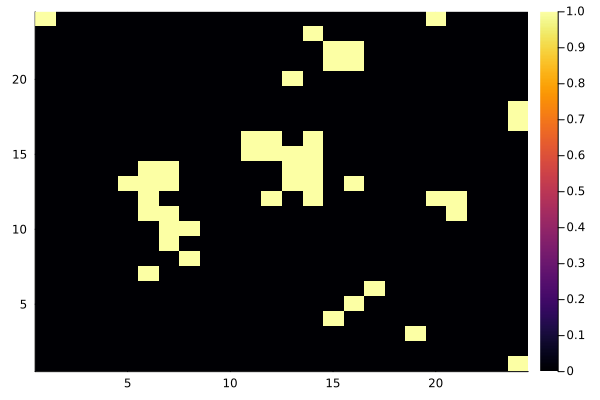

In [472]:
Plots.heatmap(M1s[40,:,:])

In [328]:
L = 32
ℓ = 4
q = 0.1

ρ = zeros(Bool, L, L)
ρ[L÷2-ℓ÷2:L÷2+ℓ÷2,L÷2-ℓ÷2:L÷2+ℓ÷2] .= true

samples = 10
T = 2L
M1s, _ = adv_MWPM_sample_hotstart(ρ, L, T, 0.0, q, q, samples)

([0.0244140625, 0.0201171875, 0.0150390625, 0.0154296875, 0.01240234375, 0.009765625, 0.007421875, 0.0072265625, 0.008203125, 0.00537109375  …  0.00068359375, 0.000390625, 0.000390625, 0.000390625, 0.000390625, 0.0001953125, 0.0001953125, 0.00068359375, 0.000390625, 0.0005859375], [0.0, 0.0005014419555664062, 0.00036334991455078125, 0.00039310455322265624, 0.00030317306518554685, 0.0002338409423828125, 0.0001789093017578125, 0.0001651763916015625, 0.00017757415771484374, 0.00010690689086914062  …  2.002716064453125e-6, 5.7220458984375e-7, 3.814697265625e-7, 3.814697265625e-7, 5.7220458984375e-7, 1.9073486328125e-7, 1.9073486328125e-7, 8.58306884765625e-7, 5.7220458984375e-7, 7.62939453125e-7])

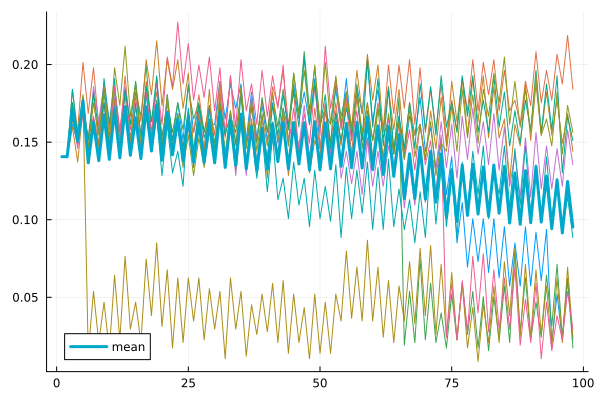

In [348]:
L = 24
ℓ = 8
q = 0.1
p = 0.04

ρ = zeros(Bool, L, L)
ρ[L÷2-ℓ÷2:L÷2+ℓ÷2,L÷2-ℓ÷2:L÷2+ℓ÷2] .= true

samples = 10
T = 2L

meanM1s = zeros(Float64, 2T+2)

plt = plot()
for _ in 1:samples
    M1s = adv_MWPM_sample_hotstart(ρ, L, T, p, q, q)
    M1s[1] = magnetization(ρ)
    M1s[2] = magnetization(ρ)
    meanM1s .+= M1s
    plot!(plt, M1s, label="")
end
meanM1s ./= samples
plot!(plt, meanM1s, linewidth=3, label="mean")
plt

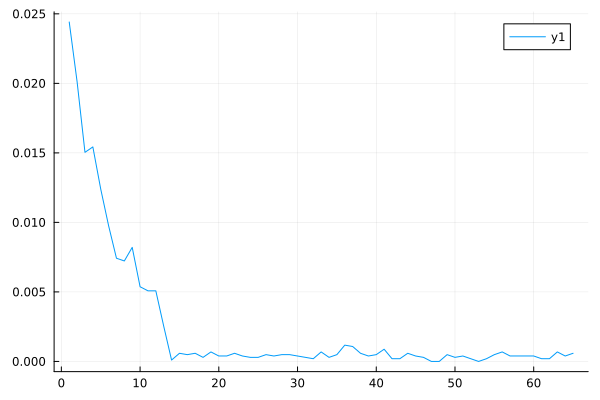

In [329]:
plot(M1s)

Original: 0.006103515625


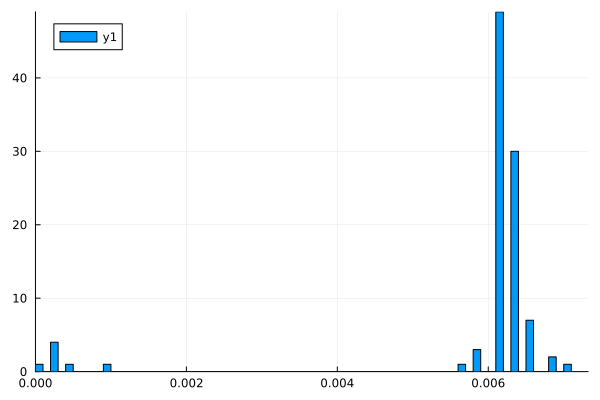

In [310]:
L = 64
ℓ = 4
q = 0.1

ρ = zeros(Bool, L, L)
ρ[L÷2-ℓ÷2:L÷2+ℓ÷2,L÷2-ℓ÷2:L÷2+ℓ÷2] .= true
original = mean(ρ)
println("Original: $original")

samples = 100
means = zeros(samples)


for i in 1:samples
    ρ = zeros(Bool, L, L)
    ρ[L÷2-ℓ÷2:L÷2+ℓ÷2,L÷2-ℓ÷2:L÷2+ℓ÷2] .= true
    means[i] = mean(correct(ρ, q, q))
end
histogram(means, bins=100, xlim=(0,1.2original))

In [11]:
ρ = [0 0 0 0 1 1 0 0
     0 0 0 0 0 0 0 0
     0 0 0 0 0 0 0 0
     1 1 0 0 0 0 0 0
     1 1 0 0 0 0 0 0
     0 0 0 0 0 0 0 0
     0 0 0 0 0 0 0 0
     0 0 0 0 0 0 0 0]

horizontal_checks, vertical_checks = measure(ρ, 0.0)
detect_charges(horizontal_checks, vertical_checks)

Tuple{Int64, Int64}[]

In [10]:
horizontal_checks

8×8 Matrix{Int64}:
 0  0  0  0  1  1  0  0
 0  0  0  0  0  0  0  0
 1  1  0  0  0  0  0  0
 1  1  0  0  0  0  0  0
 1  1  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  1  1  0  0

In [8]:
horizontal_checks = [0 0 0 0 1 1 0 0
                     0 0 0 0 0 0 0 0
                     1 1 0 0 0 0 0 0
                     1 1 0 0 0 0 0 0
                     1 1 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 1 1 0 0]

vertical_checks = [0 0 0 1 0 1 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 1 0 0 0 0 0 1
                   0 1 0 0 0 0 0 1
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0]

8×8 Matrix{Int64}:
 0  0  0  1  0  1  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  1  0  0  0  0  0  1
 0  1  0  0  0  0  0  1
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0

In [9]:
detect_charges(horizontal_checks, vertical_checks)

2-element Vector{Tuple{Int64, Int64}}:
 (2, 4)
 (8, 4)

In [184]:
include(joinpath(ROOT, "src", "mwpm.jl"))
new_horizontal_checks, new_vertical_checks = heal((BitMatrix(horizontal_checks), BitMatrix(vertical_checks)), 0.0, 0.0)

new_horizontal_checks

8×8 BitMatrix:
 0  0  0  0  1  1  0  0
 0  0  0  0  0  0  0  0
 1  1  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 1  1  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  1  1  0  0

In [179]:
new_horizontal_checks

8×8 BitMatrix:
 0  0  0  0  1  1  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  1  1  0  0

In [163]:
vertical_checks[2, 4]

false

In [151]:
unsite(L, 8)

(8, 1)

In [150]:
site(L, 8, 1)

8

In [170]:
checks = (BitMatrix(horizontal_checks), BitMatrix(vertical_checks))
horizontal_checks, vertical_checks = deepcopy(boundary_filter(checks))
L = size(horizontal_checks)[1]
charges = detect_charges(horizontal_checks, vertical_checks)

if length(charges) == 0
    return horizontal_checks, vertical_checks
end

g = build_matching_graph_syndrome_only((horizontal_checks, vertical_checks))

fw = floyd_warshall_shortest_paths(g)
match = match_charges(fw, charges, L)

6


MatchingResult{Float64}(0.0, [2, 1, 4, 3, 6, 5])

In [172]:
g.weights[site(L, 2, 3), site(L, 2, 4)]

0.0

In [176]:
vertical_checks[5,2]

true

In [158]:
match.mate[1]

2

In [154]:
charges

6-element Vector{Tuple{Int64, Int64}}:
 (2, 3)
 (2, 4)
 (4, 8)
 (6, 8)
 (8, 3)
 (8, 5)

In [161]:
fw.dists[site(L,2,3), site(L,2,4)]

Inf

In [116]:
charges

2-element Vector{Tuple{Int64, Int64}}:
 (8, 3)
 (8, 5)

In [112]:
fw.dists[site(L,charges[1]...), site(L,charges[4]...)]

Inf

In [93]:
g = build_matching_graph_syndrome_only((BitMatrix(horizontal_checks), BitMatrix(vertical_checks)))

{64, 30} undirected simple Int64 graph with Float64 weights

In [105]:
detect_charges(deepcopy(boundary_filter((horizontal_checks, vertical_checks)))...)

4-element Vector{Tuple{Int64, Int64}}:
 (4, 8)
 (6, 8)
 (8, 3)
 (8, 5)

In [121]:
include(joinpath(ROOT, "src", "mwpm.jl"))
new_horizontal_checks, new_vertical_checks = heal((BitMatrix(horizontal_checks), BitMatrix(vertical_checks)), 0.0, 0.0)

4


(Bool[0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0], Bool[0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0])

In [126]:
new_horizontal_checks == horizontal_checks

true

In [127]:
new_vertical_checks == vertical_checks

true

In [82]:
vertical_checks[1,6]

1

In [ ]:
ρ

In [75]:
detect_charges(horizontal_checks, vertical_checks)

Tuple{Int64, Int64}[]

In [65]:
horizontal_checks = [0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 1 1 1 1 1 1 0
                     1 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     1 1 1 1 1 1 1 1
                     ]

vertical_checks = [0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   1 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   ]

8×8 Matrix{Int64}:
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 1  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0

In [71]:
horizontal_checks = [0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     ]

vertical_checks = [0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   1 0 0 0 0 0 0 1
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   ]

8×8 Matrix{Int64}:
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 1  0  0  0  0  0  0  1
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0

In [72]:
detect_charges(horizontal_checks, vertical_checks)

4-element Vector{Tuple{Int64, Int64}}:
 (1, 4)
 (1, 5)
 (8, 4)
 (8, 5)

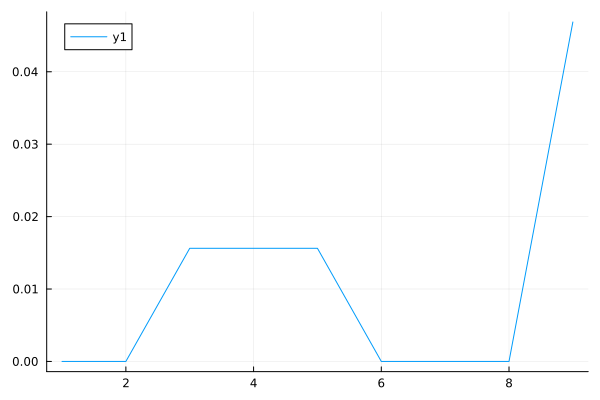

In [12]:
plot(data2["M1s"])

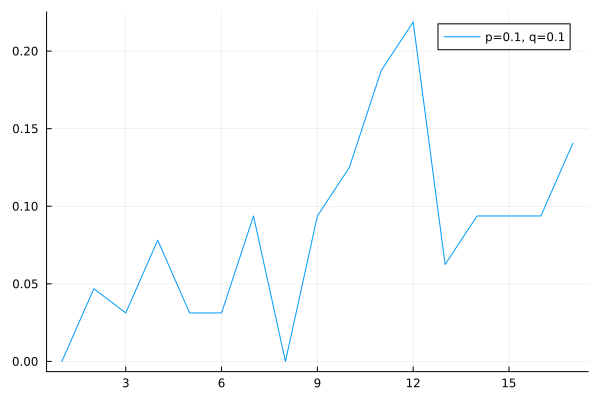

In [8]:
plot(data[(8, 0.1, 0.1, 0.1)], label="p=0.1, q=0.1")

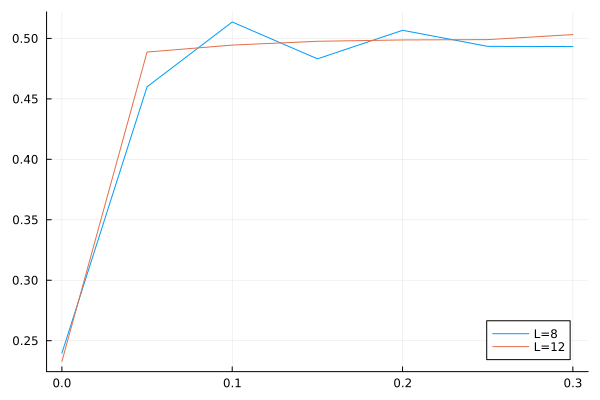

In [41]:
q = 0.3
plt = plot()

for L in [8, 12]
    ps = 0.0:0.05:0.3
    M1s = [data[(L, p, q, q)][end] for p in ps]
    plot!(plt, ps, M1s, label="L=$L")
end
plt

In [ ]:
L = 8
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 100
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)

# each job can be 10L & 10k samples

([0.0, 0.369375, 0.4428125, 0.49671875, 0.52734375, 0.5009375, 0.47671875, 0.4871875, 0.48609375, 0.4790625, 0.5025, 0.4959375, 0.5140625, 0.5190625, 0.52765625, 0.50265625, 0.49078125], [0.0, 0.154990234375, 0.229345703125, 0.29035400390625, 0.31264404296875, 0.2945068359375, 0.27453857421875, 0.2723828125, 0.28670166015625, 0.2672314453125, 0.2889892578125, 0.296220703125, 0.302314453125, 0.322001953125, 0.32752197265625, 0.29644287109375, 0.29166259765625])

In [21]:
L = 24
p = 0.04
q = 0.2
peff = q
T = 2L
samples = 100
M1ss, _ = adv_MWPM_sample(L, T, p, peff, q, samples)


([0.0, 0.030694444444444448, 0.0489236111111111, 0.06258680555555556, 0.07192708333333334, 0.07956597222222223, 0.08538194444444447, 0.09196180555555555, 0.09809027777777779, 0.10350694444444444  …  0.15262152777777777, 0.15401041666666665, 0.15602430555555555, 0.1573263888888889, 0.16, 0.16262152777777786, 0.16427083333333328, 0.16690972222222225, 0.16739583333333333, 0.16918402777777772], [0.0, 0.001009235146604939, 0.0025130208333333333, 0.004062530140817903, 0.005366180796682103, 0.006545410156250001, 0.0075494912229938285, 0.008841899353780863, 0.010093557098765431, 0.011224983121141972  …  0.02508080753279321, 0.02548366970486111, 0.026077323254243823, 0.02655056423611111, 0.027489691840277778, 0.02831666546103394, 0.02927053192515432, 0.02998480902777778, 0.030514142071759256, 0.031100290557484568])

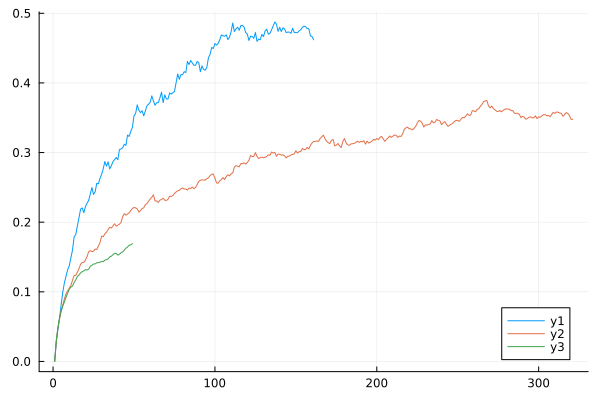

In [22]:
plot!(M1ss)

In [ ]:
L = 24
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 10
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
# each job can be 10L & 1k samples

([0.0, 0.4335069444444445, 0.4677083333333334, 0.46215277777777775, 0.5003472222222222, 0.5446180555555555, 0.47517361111111106, 0.44045138888888885, 0.4442708333333333, 0.4767361111111111  …  0.5362847222222221, 0.5144097222222223, 0.4722222222222222, 0.4690972222222222, 0.5218749999999999, 0.48315972222222214, 0.4859375, 0.5104166666666667, 0.4838541666666667, 0.5144097222222224], [0.0, 0.1929961781442901, 0.22284131462191356, 0.2192220052083333, 0.25856782889660496, 0.3000569661458333, 0.23491843894675926, 0.1982623818479938, 0.19977303964120371, 0.23271243248456788  …  0.29093092930169756, 0.2749653380594136, 0.22817563657407405, 0.2238329475308642, 0.27715145158179016, 0.23953179253472223, 0.24205397617669755, 0.2689037181712963, 0.2417519651813272, 0.27313337914737656])

In [ ]:
L = 32
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 1
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
# each job can be 10L & 200 samples

([0.0, 0.4248046875, 0.5107421875, 0.5087890625, 0.458984375, 0.390625, 0.4765625, 0.6103515625, 0.4423828125, 0.642578125  …  0.4765625, 0.5244140625, 0.6669921875, 0.421875, 0.4296875, 0.525390625, 0.3837890625, 0.5625, 0.486328125, 0.515625], [0.0, 0.18045902252197266, 0.26085758209228516, 0.2588663101196289, 0.21066665649414062, 0.152587890625, 0.22711181640625, 0.3725290298461914, 0.19570255279541016, 0.4129066467285156  …  0.22711181640625, 0.2750101089477539, 0.44487857818603516, 0.177978515625, 0.18463134765625, 0.2760353088378906, 0.1472940444946289, 0.31640625, 0.23651504516601562, 0.265869140625])

In [50]:
L = 40
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 1
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)

([0.0, 0.420625, 0.449375, 0.543125, 0.470625, 0.514375, 0.44375, 0.5025, 0.541875, 0.528125  …  0.451875, 0.446875, 0.466875, 0.49125, 0.49875, 0.415625, 0.503125, 0.514375, 0.591875, 0.53], [0.0, 0.176925390625, 0.20193789062500003, 0.294984765625, 0.22148789062500002, 0.264581640625, 0.1969140625, 0.25250624999999993, 0.293628515625, 0.27891601562499996  …  0.20419101562500003, 0.199697265625, 0.217972265625, 0.2413265625, 0.24875156250000002, 0.17274414062500001, 0.25313476562500004, 0.264581640625, 0.35031601562500003, 0.28090000000000004])

In [1]:
using JLD2

In [5]:
path = "../output/collated_results.jld2"
data = load(path)["results"]

Dict{NTuple{6, Any}, Tuple{Vector, Vector, Int64, Float64}} with 2124 entries:
  ("adv_MWPM", 4, 4, 0.05,… => ([0.0, 0.0344678, 0.0487441, 0.0580966, 0.066986…
  ("adv_MWPM", 8, 8, 0.05,… => ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], …
  ("adv_MWPM", 12, 12, 0.0… => ([0.0, 0.0217361, 0.030191, 0.0326215, 0.0337847…
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.00506445, 0.00549414, 0.00576367, 0.005…
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.0328398, 0.0515938, 0.0612148, 0.067709…
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.0580469, 0.110393, 0.148473, 0.176557, …
  ("adv_MWPM", 4, 4, 0.05,… => ([0.0, 0.0100434, 0.0120609, 0.0128491, 0.013395…
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.013791, 0.0165137, 0.0175078, 0.0176973…
  ("adv_MWPM", 8, 8, 0.05,… => ([0.0, 0.0671641, 0.111191, 0.141182, 0.166275, …
  ("adv_MWPM", 12, 12, 0.0… => ([0.0, 0.0758194, 0.140712, 0.192868, 0.241851, …
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.0258672, 0.0388262, 0.0471465, 0.051570…
  ("adv_MWPM", 12, 12, 0.0… =>

In [6]:
p = 0.2

plt = plot()

Ls = unique([key[2] for key in keys(data) if key[4] == p])
for L in Ls
    Ts = unique([key[3] for key in keys(data) if key[4] == p && key[2] == L])
    for T in Ts[1:end]
        peffs = unique([key[6] for key in keys(data) if key[4] == p && key[2] == L && key[3] == T])
        for peff in peffs[1:2]
            qs = unique([key[5] for key in keys(data) if key[4] == p && key[2] == L && key[3] == T && key[6] == peff])
            println(sort(qs))
            Ms = [data[("adv_MWPM", L, T, p, q, peff)][1][end] for q in qs]
            plot!(plt, qs, Ms, label="L=$L, T=$T, peff=$peff")
        end
    end
end
plt

InterruptException: InterruptException:

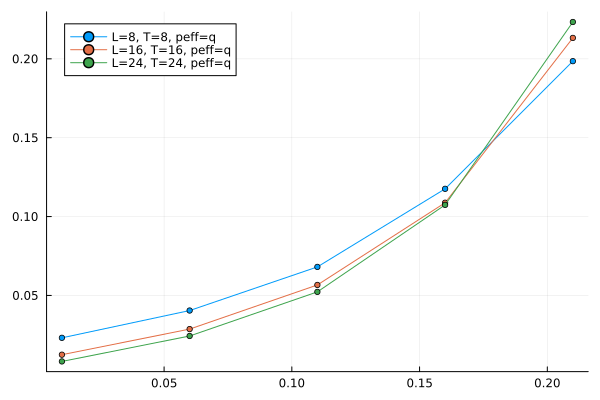

In [7]:
p = 0.05
plt = plot()
for L in 8:8:24
    T = L

    # peffs = sort(unique([key[6] for key in keys(data) if key[1] == "adv_MWPM" && key[2] == L && key[3] == T && key[4] == p]))
    # println(peffs)
    qs = 0.01:0.05:0.25
    Ms = [data[("adv_MWPM", L, T, p, q, q)][1][end] for q in qs]
    plot!(plt, qs, Ms, label="L=$L, T=$T, peff=q", m=3)
end
plt

In [9]:
# ML

unique([(key[2], key[3], data[key][3]) for key in keys(data) if key[1] == "adv_MWPM"])

18-element Vector{Tuple{Int64, Int64, Int64}}:
 (4, 4, 200000)
 (8, 8, 20000)
 (12, 12, 2000)
 (16, 16, 2000)
 (16, 16, 4000)
 (16, 16, 1000)
 (24, 24, 2000)
 (20, 20, 2000)
 (12, 12, 4000)
 (4, 4, 300000)
 (8, 8, 30000)
 (8, 80, 50000)
 (24, 240, 499)
 (16, 160, 500)
 (16, 160, 490)
 (24, 240, 501)
 (24, 240, 500)
 (24, 24, 2020)

In [ ]:
using Plots

In [ ]:
L = 104
T = 20L
p = 0.1
q = 0.1
samples = 10
M1s, M2s = MV_sample(L, T, p, q, samples) 

In [ ]:
plot(mean.(M1s))

In [ ]:
# data = load("../sample_algo=MV_L=8_T=16_p=0p050_q=0p100_samples=10_20260224_052232_3250195359.jld2")
# data

In [ ]:
# using GraphsMatching

In [ ]:
# data = Dict{Tuple{Int, Float64, Float64, Float64}, Vector{Float64}}()

In [ ]:
samples = 1

for p in 0.0:0.01:0.3
    for q in 0.0:0.01:0.2
        peff = q
        for L in [8]#, 16]
            T = 2L

            M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
            data[(L, p, q, peff)] = M1s
        end
    end
end

In [ ]:
L = 12
p = 0.2
q = 0.05
peff = q
T = 2L
samples = 100

M1s, M2s = adv_MWPM_sample(L, T, p, peff, q, samples)

In [ ]:
plot(M1s)

In [ ]:
L = 8
p = 0.3
q = 0.15
peff = 0.45
T = 2L
samples = 10000

M1s, M2s = adv_MWPM_sample(L, T, p, peff, q, samples)

plot(M1s, label="L=8")

L = 12
M1s, M2s = adv_MWPM_sample(L, T, p, peff, q, samples)
plot!(M1s, label="L=12")

In [ ]:
plot(M1s)

In [ ]:
L = 20
p = 0.1
q = 0.1
peff = 0.15
T = 1

ρ = initialstate(L)
Ms = zeros(Float64, T+1)

for t in 1:T
    ρ = noiselayer(ρ, p)

    checks = measure(ρ, q)
    
    t0 = time()
    horizontal_checks, vertical_checks = heal(checks, peff, q)
    println("Healing took $(time() - t0) seconds.")

    domain = track_domains((horizontal_checks, vertical_checks))
    if magnetization(domain) > 0.5
        domain = .!domain
    end
    
    ρ = ρ .⊻ domain

    Ms[t+1] = magnetization(ρ)
end



In [ ]:
L = 20
p = 0.3
q = 0.1
peff = 0.5
T = 2L

ρ = initialstate(L)
Ms = zeros(Float64, T+1)

for t in 1:T
    ρ = noiselayer(ρ, p)

    ρ = correct(ρ, peff, q)

    Ms[t+1] = magnetization(ρ)
end



In [ ]:
plot(Ms)

In [ ]:
L = 40
p = 0.1
q = 0.15
peff = 0.2
ρ  = initialstate(L)
ρ = noiselayer(ρ, p)

checks = measure(ρ, q)

horizontal_checks, vertical_checks = deepcopy(boundary_filter(checks))
L = size(horizontal_checks)[1]
charges = detect_charges(horizontal_checks, vertical_checks)

# println(charges)

if length(charges) == 0
    return horizontal_checks, vertical_checks
end

g = build_matching_graph((horizontal_checks, vertical_checks), peff, q)

t1 = time()
fw = floyd_warshall_shortest_paths(g)
t2 = time()
match = match_charges(fw, charges, L)
t3 = time()

println("Floyd-Warshall time: ", t2 - t1)
println("Matching time: ", t3 - t2)

In [ ]:
fw.parents[1, 20]

In [ ]:
using PyQDecoders
using PyQDecoders: sps, np, pm

In [ ]:
function adv_MWPM_sample(L::Int, T::Int, p::Float64, peff::Float64, q::Float64)
    ρ = initialstate(L)
    Ms = zeros(Float64, T+1)

    for t in 1:T
        ρ = noiselayer(ρ, p)
        ρ = correct(ρ, peff, q)
        Ms[t+1] = magnetization(ρ)
    end

    return Ms
end

In [ ]:
function correct(ρ::AbstractMatrix, peff::Float64, q::Float64)
    checks = measure(ρ, q)
    
    horizontal_checks, vertical_checks = heal(checks, peff, q)
    domain = track_domains((horizontal_checks, vertical_checks))
    if magnetization(domain) > 0.5
        domain = .!domain
    end
    
    return ρ .⊻ domain
end

In [ ]:
function detect_charges(horizontal_checks::AbstractMatrix, vertical_checks::AbstractMatrix)
    L = size(vertical_checks)[1]
    sites = vertical_checks .⊻ horizontal_checks .⊻ circshift(vertical_checks,(-1,0)) .⊻ circshift(horizontal_checks,(0,-1))
    return [(j,i) for i in 1:L, j in 1:L][Bool.(sites)]
end

prob_weight(x::Float64) = -log(x/(1-x))
weight(peff::Float64, q::Float64, m::Bool) = (-1)^m * prob_weight(peff) + prob_weight(q)

site(L,x,y) = L*(mod1(y,L)-1)+mod1(x,L)
unsite(L,s) = (mod1(s,L), div(s-1,L)+1)

function build_matching_graph(checks::Tuple, peff::Float64, q::Float64)
    horizontal_checks, vertical_checks = checks
    L = size(horizontal_checks)[1]
    
    sources = [site(L,x,y) for y in 1:L for x in 1:L]
    horizontal_destinations = [site(L,x+1,y) for y in 1:L for x in 1:L]
    vertical_destinations = [site(L,x,y+1) for y in 1:L for x in 1:L]
    
    horizontal_weights = weight.(peff, q, Bool.(horizontal_checks))
    horizontal_weights[end,:] .= 0
    horizontal_weights = reshape(circshift(horizontal_weights,(0,-1))', L^2, 1)[:,1]

    vertical_weights = weight.(peff, q, Bool.(vertical_checks))
    vertical_weights[:,end] .= 0
    vertical_weights = reshape(circshift(vertical_weights,(-1,0))', L^2, 1)[:,1]
    
    return SimpleWeightedGraph([sources; sources], [horizontal_destinations; vertical_destinations], [horizontal_weights; vertical_weights])
end

function match_charges(fw::Graphs.FloydWarshallState, charges::Vector, L::Int; depth=50)
    subgraph = complete_graph(length(charges))
    weights = Dict{Edge,Float64}()
    for i in 1:length(charges)-1
        for j in i+1:length(charges)
            # if fw.dists[charges[i],charges[j]] < Inf
                weights[Edge(i, j)] = fw.dists[site(L,charges[i]...),site(L,charges[j]...)]
            # end
        end
    end

    match = minimum_weight_perfect_matching(subgraph, weights, depth)
    return match
end

function boundary_filter(checks::Tuple)
    horizontal_checks, vertical_checks = deepcopy(checks)
    L = size(horizontal_checks)[1]
    
    horizontal_checks[end,:] .= false
    vertical_checks[:,end] .= false
    
    return horizontal_checks, vertical_checks
end

cyclicmax(L, a, b) = mod(a-b-1, L) == 0 ? a : b 


function heal(checks::Tuple, peff::Float64, q::Float64)
    t1 = time()
    horizontal_checks, vertical_checks = deepcopy(boundary_filter(checks))
    L = size(horizontal_checks)[1]
    charges = detect_charges(horizontal_checks, vertical_checks)

    # println(charges)

    if length(charges) == 0
        return horizontal_checks, vertical_checks
    end
    
    g = build_matching_graph((horizontal_checks, vertical_checks), peff, q)
    fw = floyd_warshall_shortest_paths(g)
    match = match_charges(fw, charges, L)


    t2 = time()

    horizontal_checkes, vertical_checks = apply_paths((horizontal_checks, vertical_checks), fw, match, charges, L)

    # println("Matching took $(t2 - t1) seconds.")
    # println("Pathing took $(time() - t2) seconds.")

    return horizontal_checks, vertical_checks
end

function apply_paths(checks::Tuple, fw::Graphs.FloydWarshallState, match::MatchingResult, charges::Vector, L::Int)
    horizontal_checks, vertical_checks = checks
    mated = Int[]

    for i in 1:length(charges)
        j = match.mate[i]
        if j in mated
            continue
        end

        # while loop path backwards
        
        s0 = site(L, charges[i]...)
        s2 = site(L, charges[j]...)
        while s0 != s2
            s1 = fw.parents[s0, s2]
            x1, y1 = unsite(L, s1)
            x2, y2 = unsite(L, s2)
            if x1 == x2
                vertical_checks[cyclicmax(L, y1, y2), x1] ⊻= true
            elseif y1 == y2
                horizontal_checks[y1, cyclicmax(L, x1, x2)] ⊻= true
            end

            s2 = s1
        end

        push!(mated, i)
        push!(mated, j)
    end
    return horizontal_checks, vertical_checks
end